# Training (YOLO Model)

This notebook contains the code used to perform the main training loop for the YOLO26 based human pose estimation model. The actual training code in implemented in `detect.py`.

In [ ]:
import sys

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Add the `code` directory to the path.
sys.path.append("../")

import util
import detect
import dataset

In [3]:
# This code is just here so I can reload the external files in case I make
# changes to them after having already imported them.
import importlib

importlib.reload(util)
importlib.reload(detect)
importlib.reload(dataset);

We now train the custom YOLO head with the complete dataset. 

In [ ]:
model = detect.CustomHeadedYolo(path="../nets")

# Train for a maximum of 50 epochs on the complete dataset.
detect.train_epochs_in(50, "../nets/yolo", "../stats/yolo", model)

Loaded checkpoint for step 8.
epoch 9; train: loss 11.269923969677516; val: loss 11.056220265177938
epoch 10; train: loss 11.216468943868364; val: loss 11.160030550770946
epoch 11; train: loss 11.026612860815865; val: loss 11.652641333542862
epoch 12; train: loss 10.919876292773656; val: loss 10.899042129516602


In [ ]:
util.NetStorage.training_stats("../stats/yolo").sort_values("step") \
    .to_csv("../stats/yolo.csv", index=False)

Below we look at some examples of applying the learned detector on some example images.

In [ ]:
# Load one example sample from the dataset.
data = dataset.YoloDataset("../data/yolo/val")
img, ann = data[10]
# Try to run the learned detector on the sample.
detector = detect.CustomPoseDetector(model)
mean, cov = detector.detect_simple(img.unsqueeze(0).to("cuda"))[0]
# Try also to use the baseline YOLO model.
detector2 = detect.PoseDetector(path="../nets", compile=False)
mean2, cov2 = detector2.detect_simple(img.unsqueeze(0))[0]

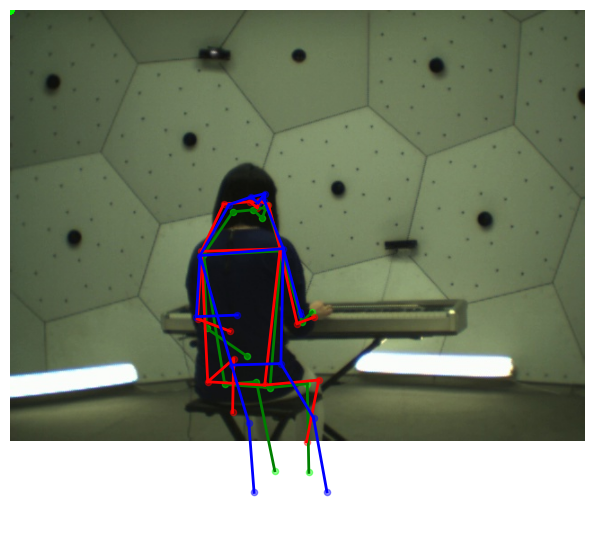

In [ ]:
# Visualize the results.
plt.figure(figsize=(8, 7))
for kp in ann:
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='green', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#00ff0070')
for kp in mean2.cpu().view(-1, 17, 2):
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='red', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#ff000070')
for kp in mean.cpu().view(-1, 17, 2):
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='blue', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#0000ff70')
plt.imshow(img.permute(1, 2, 0))
plt.ylim(600, 0)
plt.axis("off")
plt.show()

#### Training and Validation Loss Curves

Below we will examine the training and validation loss curves for the training run.

In [ ]:
df = pd.read_csv("../stats/yolo.csv").sort_values("step")

plt.plot(df["step"], df["tr_loss"], label="Train")
plt.plot(df["step"], df["val_loss"], label="Validation")
plt.ylabel("Combined MSE and NLL Loss")
plt.xlabel("Epoch")
plt.legend()
plt.tight_layout()
plt.savefig(f"../../presentation1/figures/lcurve-yolo.pdf",
            format="pdf", bbox_inches='tight', pad_inches=0)
plt.show()